In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('../Datasets/drug_discovery_virtual_screening.csv')

df.head()

,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0


In [5]:
df.shape

(2000, 17)

In [6]:
df.isnull().sum()   

compound_id             0
protein_id              0
molecular_weight        0
logp                   60
h_bond_donors           0
h_bond_acceptors        0
rotatable_bonds         0
polar_surface_area     60
compound_clogp          0
protein_length          0
protein_pi              0
hydrophobicity         60
binding_site_size       0
mw_ratio                0
logp_pi_interaction     0
binding_affinity        0
active                  0
dtype: int64

In [7]:
df['logp'] = df['logp'].fillna(df['logp'].mean())
df['polar_surface_area'] = df['polar_surface_area'].fillna(df['polar_surface_area'].mean())
df['hydrophobicity'] = df['hydrophobicity'].fillna(df['hydrophobicity'].mean())

In [8]:
df.isnull().sum()

compound_id            0
protein_id             0
molecular_weight       0
logp                   0
h_bond_donors          0
h_bond_acceptors       0
rotatable_bonds        0
polar_surface_area     0
compound_clogp         0
protein_length         0
protein_pi             0
hydrophobicity         0
binding_site_size      0
mw_ratio               0
logp_pi_interaction    0
binding_affinity       0
active                 0
dtype: int64

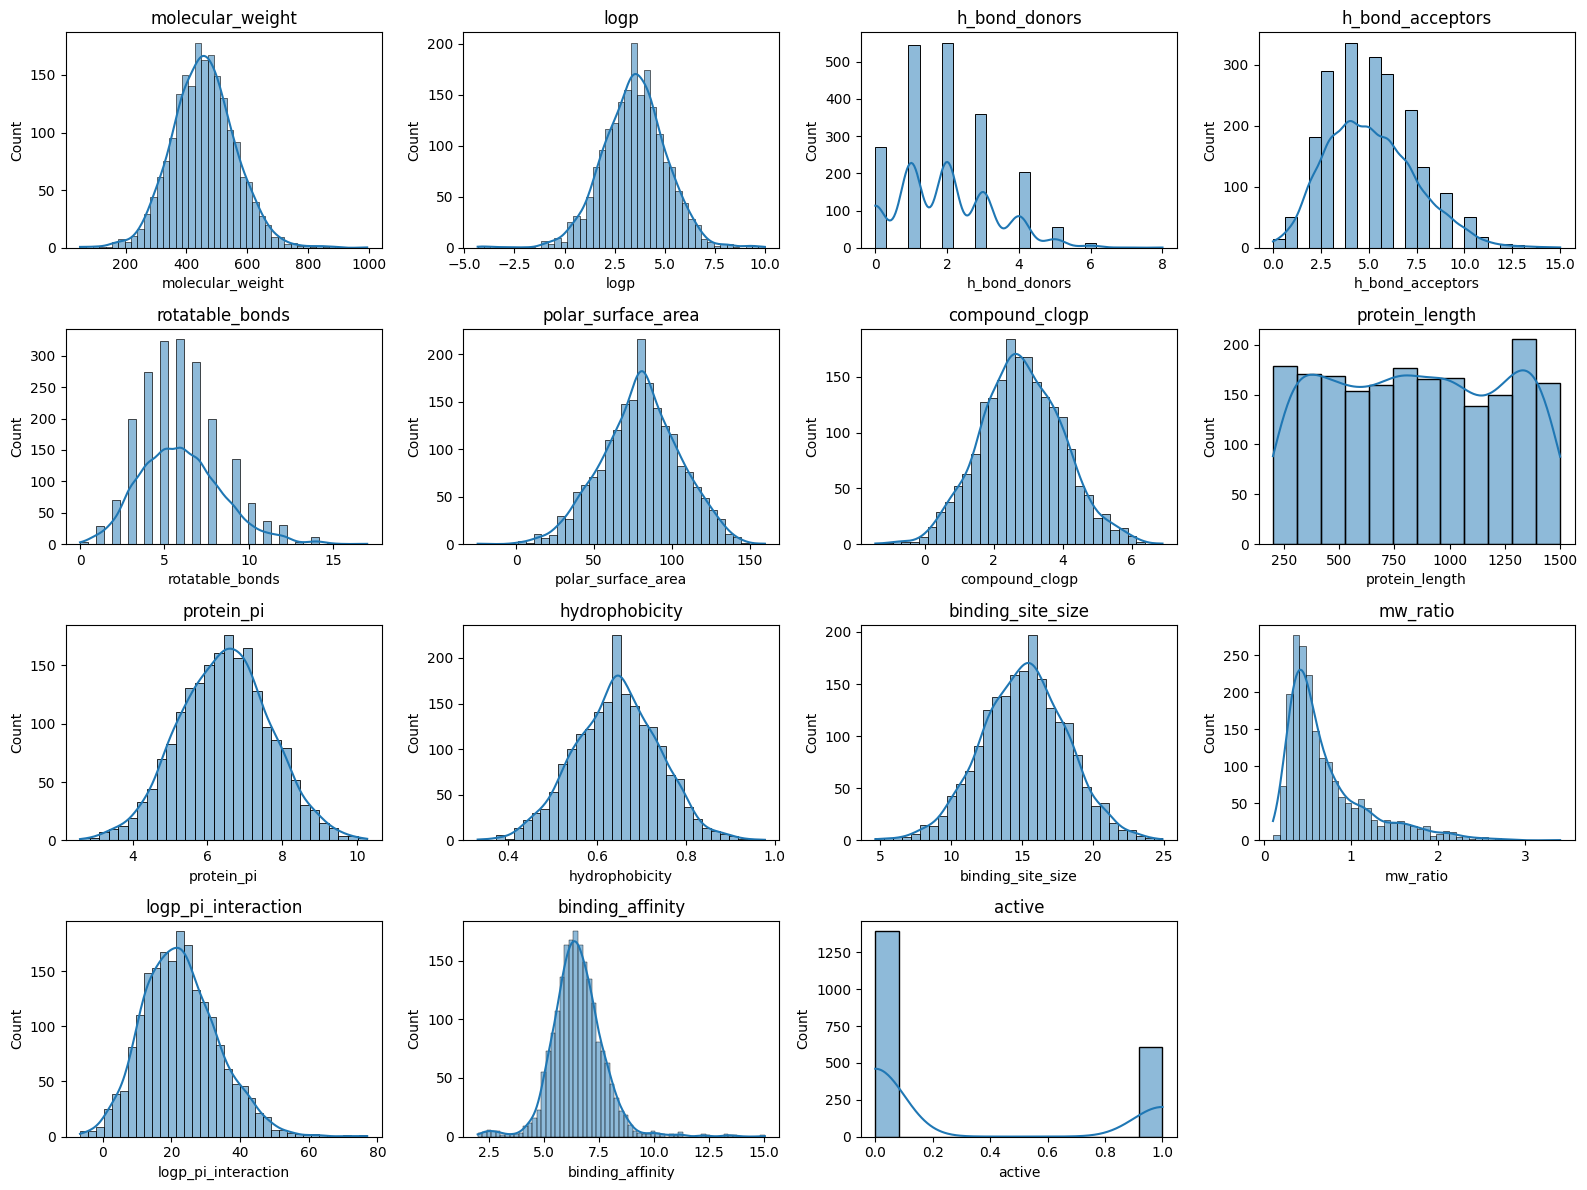

In [9]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

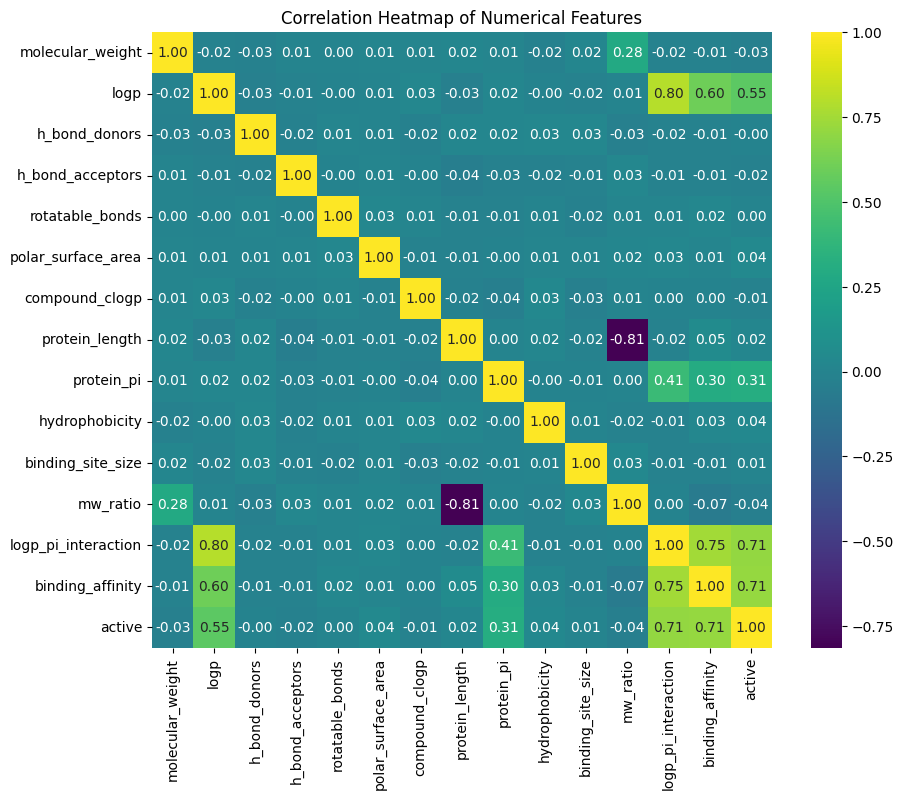

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [11]:
X=df.drop(['compound_id','protein_id' ,'active'], axis=1)
y=df['active']  

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}


In [14]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

/Users/swara/Desktop/ey/EY_Techathon/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


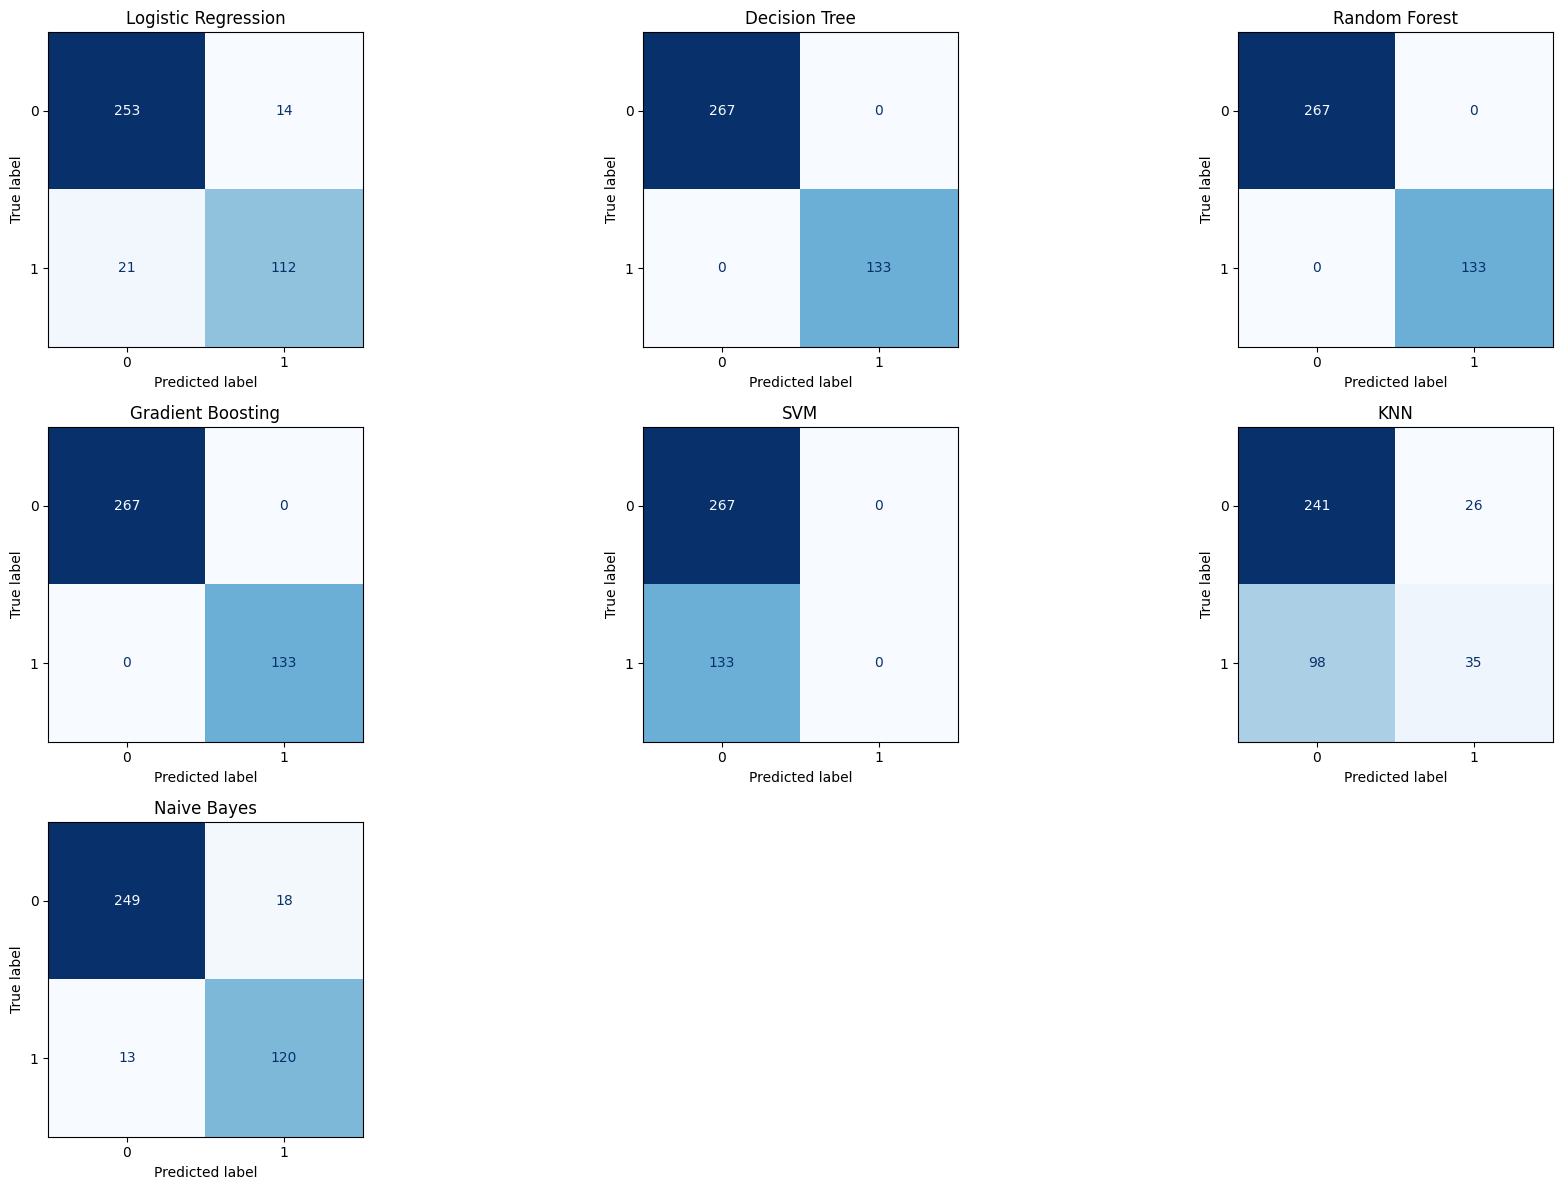

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


plt.figure(figsize=(18, 12))
for i, (name, clf) in enumerate(classifiers.items(), 1):
    clf.fit(X_train_imputed, y_train)
    y_pred = clf.predict(X_test_imputed)
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(3, 3, i)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=plt.gca(), cmap='Blues', colorbar=False)
    plt.title(name)
plt.tight_layout()
plt.show()

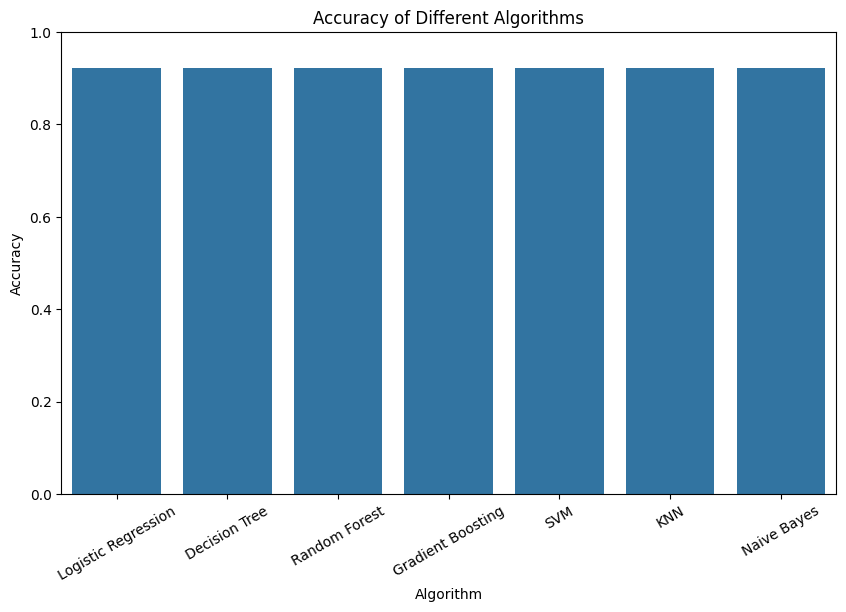

In [16]:
from sklearn.metrics import accuracy_score

accuracies = []
names = []

for name, clf in classifiers.items():
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    names.append(name)

plt.figure(figsize=(10, 6))
sns.barplot(x=names, y=accuracies)
plt.ylabel('Accuracy')
plt.xlabel('Algorithm')
plt.title('Accuracy of Different Algorithms')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

In [17]:
for name, acc in zip(names, accuracies):
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9225
Decision Tree: 0.9225
Random Forest: 0.9225
Gradient Boosting: 0.9225
SVM: 0.9225
KNN: 0.9225
Naive Bayes: 0.9225


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ------------------------------
# Load dataset
# ------------------------------
# ------------------------------
# Define features and target
# ------------------------------
features = ['molecular_weight', 'logp', 'h_bond_donors', 'h_bond_acceptors',
            'rotatable_bonds', 'polar_surface_area', 'compound_clogp', 'protein_length',
            'protein_pi', 'hydrophobicity', 'binding_site_size', 'mw_ratio', 'logp_pi_interaction']

X = df[features]
y = df['active']

# ------------------------------
# Handle missing values
# ------------------------------
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# ------------------------------
# Scale features
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ------------------------------
# Train/test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ------------------------------
# Train classifier
# ------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate accuracy
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# ------------------------------
# Protein mapping for diseases
# ------------------------------
protein_mapping = {
    'Fever': 'PID_222',    # Replace with actual protein IDs
    'Diabetes': 'Q67890'
}

# ------------------------------
# Function: Suggest Drugs for a Disease
# ------------------------------
def suggest_drug(disease_name, protein_mapping, model, scaler, df, features, top_n=3):
    # Map disease to protein_id
    protein_id = protein_mapping.get(disease_name)
    if protein_id is None:
        return f"Protein target not found for disease '{disease_name}'"

    # Filter compounds that can bind this protein
    subset = df[df['protein_id'].astype(str) == str(protein_id)].copy()
    
    if subset.empty:
        return f"No compounds available for disease '{disease_name}'"

    # Handle missing values
    imputer = SimpleImputer(strategy='mean')
    X_subset = imputer.fit_transform(subset[features])
    
    # Scale features
    X_subset = scaler.transform(X_subset)
    
    # Predict probability of being active
    probs = model.predict_proba(X_subset)[:, 1]
    subset['probability_of_cure'] = probs
    
    # Return top_n compounds
    top_drugs = subset.sort_values('probability_of_cure', ascending=False).head(top_n)
    return top_drugs[['compound_id', 'probability_of_cure']]

# ------------------------------
# Example Usage
# ------------------------------
result = suggest_drug('Fever', protein_mapping, model, scaler, df, features, top_n=5)
print(result)


Test Accuracy: 0.8925
     compound_id  probability_of_cure
686    CID_00686                 0.96
1415   CID_01415                 0.82
1831   CID_01831                 0.20
16     CID_00016                 0.02
246    CID_00246                 0.00


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import shap  # Explainable AI library

# ------------------------------
# Load dataset
# ------------------------------
# df = pd.read_csv('drug_dataset.csv')  # load your dataset here

# ------------------------------
# Define features and target
# ------------------------------
features = ['molecular_weight', 'logp', 'h_bond_donors', 'h_bond_acceptors',
            'rotatable_bonds', 'polar_surface_area', 'compound_clogp', 'protein_length',
            'protein_pi', 'hydrophobicity', 'binding_site_size', 'mw_ratio', 'logp_pi_interaction']

X = df[features]
y = df['active']

# ------------------------------
# Handle missing values
# ------------------------------
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# ------------------------------
# Scale features
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ------------------------------
# Train/test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ------------------------------
# Train classifier
# ------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate accuracy
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# ------------------------------
# Protein mapping for diseases
# ------------------------------
protein_mapping = {
    'Fever': 'PID_222',    # Replace with actual protein IDs
    'Diabetes': 'Q67890'
}

# ------------------------------
# Function: Suggest Drugs for a Disease with XAI
# ------------------------------
def suggest_drug_xai(disease_name, protein_mapping, model, scaler, df, features, top_n=3):
    protein_id = protein_mapping.get(disease_name)
    if protein_id is None:
        return f"Protein target not found for disease '{disease_name}'"

    # Filter compounds for protein
    subset = df[df['protein_id'].astype(str) == str(protein_id)].copy()
    if subset.empty:
        return f"No compounds available for disease '{disease_name}'"

    # Handle missing values and scale
    imputer = SimpleImputer(strategy='mean')
    X_subset = imputer.fit_transform(subset[features])
    X_subset = scaler.transform(X_subset)

    # Predict probability
    probs = model.predict_proba(X_subset)[:, 1]
    subset['probability_of_cure'] = probs

    # Top compounds
    top_drugs = subset.sort_values('probability_of_cure', ascending=False).head(top_n)

    # ------------------------------
    # SHAP Explanation
    # ------------------------------
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_subset)

    # Show SHAP values for top compounds
    print("\nSHAP feature contributions for top compounds:")
    for i, cid in enumerate(top_drugs['compound_id']):
        print(f"\nCompound: {cid}")
        shap.initjs()
        shap.force_plot(explainer.expected_value[1], shap_values[1][i,:], features=X_subset[i,:], feature_names=features, matplotlib=True)

    return top_drugs[['compound_id', 'probability_of_cure']]

# ------------------------------
# Example Usage
# ------------------------------
result = suggest_drug_xai('Fever', protein_mapping, model, scaler, df, features, top_n=3)
print(result)


/Users/swara/Desktop/ey/EY_Techathon/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test Accuracy: 0.8925

SHAP feature contributions for top compounds:

Compound: CID_00686


DimensionError: Length of features is not equal to the length of shap_values!

In [20]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.5/556.5 kB 1.6 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 1.5 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 441.6 kB/s eta 0:00:00m eta 0:00:010:00:03

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# ------------------------------
# Load dataset
# ------------------------------
# df = pd.read_csv('drug_dataset.csv')  # load your dataset here

# ------------------------------
# Define features and target
# ------------------------------
features = ['molecular_weight', 'logp', 'h_bond_donors', 'h_bond_acceptors',
            'rotatable_bonds', 'polar_surface_area', 'compound_clogp', 'protein_length',
            'protein_pi', 'hydrophobicity', 'binding_site_size', 'mw_ratio', 'logp_pi_interaction']

X = df[features]
y = df['active']

# ------------------------------
# Handle missing values
# ------------------------------
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# ------------------------------
# Scale features
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ------------------------------
# Train/test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ------------------------------
# Train classifier
# ------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate accuracy
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# ------------------------------
# Protein mapping for diseases
# ------------------------------
protein_mapping = {
    'Fever': 'PID_222',    # Replace with actual protein IDs
    'Diabetes': 'Q67890'
}

# ------------------------------
# Function: Suggest Drugs for a Disease with LIME
# ------------------------------
def suggest_drug_lime(disease_name, protein_mapping, model, scaler, df, features, top_n=3):
    print(f"\n=== Suggesting drugs for disease: {disease_name} ===")
    
    protein_id = protein_mapping.get(disease_name)
    if protein_id is None:
        return f"Protein target not found for disease '{disease_name}'"

    # Filter compounds for protein
    subset = df[df['protein_id'].astype(str) == str(protein_id)].copy()
    if subset.empty:
        return f"No compounds available for disease '{disease_name}'"

    # Handle missing values and scale
    imputer = SimpleImputer(strategy='mean')
    X_subset = imputer.fit_transform(subset[features])
    X_subset = scaler.transform(X_subset)

    # Predict probability
    probs = model.predict_proba(X_subset)[:, 1]
    subset['probability_of_cure'] = probs

    # Top compounds
    top_drugs = subset.sort_values('probability_of_cure', ascending=False).head(top_n)
    print("\nTop predicted compounds with probability of being active:")
    print(top_drugs[['compound_id', 'probability_of_cure']])

    # ------------------------------
    # LIME Explanation
    # ------------------------------
    print("\nGenerating LIME explanations for top compounds...")
    explainer = LimeTabularExplainer(X_scaled, feature_names=features, class_names=['Inactive','Active'], mode='classification')

    for i, cid in enumerate(top_drugs['compound_id']):
        print(f"\n--- Compound: {cid} ---")
        exp = explainer.explain_instance(X_subset[i], model.predict_proba, num_features=5)
        exp.show_in_notebook(show_table=True)
        exp.as_pyplot_figure()  # Optional: show as matplotlib figure
        plt.show()

    return top_drugs[['compound_id', 'probability_of_cure']]

# ------------------------------
# Example Usage
# ------------------------------
result = suggest_drug_lime('Fever', protein_mapping, model, scaler, df, features, top_n=3)
print("\nFinal Top Compounds Table:")
print(result)


Test Accuracy: 0.8925

=== Suggesting drugs for disease: Fever ===

Top predicted compounds with probability of being active:
     compound_id  probability_of_cure
686    CID_00686                 0.96
1415   CID_01415                 0.82
1831   CID_01831                 0.20

Generating LIME explanations for top compounds...

--- Compound: CID_00686 ---


ImportError: cannot import name 'display' from 'IPython.core.display' (/Users/swara/Desktop/ey/EY_Techathon/venv/lib/python3.11/site-packages/IPython/core/display.py)

In [23]:
pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/275.7 kB ? eta -:--:--  Downloading lime-0.2.0.1.tar.gz (275 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.7 MB/s eta 0:00:001.7 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.7 MB/s eta 0:00:001.7 MB/s eta 0:00:01
  Installing build dependencies ...   Installing build dependencies ... -done
  Getting requirements to build wheel ... one
  Getting requirements to build wheel ... -done
  Preparing metadata (pyproject.toml) ... one
  Preparing metadata (pyproject.toml) ... done
done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/13.2 MB ? eta -:--:--Downloading scikit_image-0.25.2-cp311-cp311-macosx_12_0_arm64.whl (13.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 867.8 kB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 867.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/315.8 kB ? eta -:--:--Downloading imagei

In [24]:
def suggest_drug(disease_name, protein_mapping, model, scaler, data, features, top_n=3):
    # Map disease to protein_id
    protein_id = protein_mapping.get(disease_name)
    if protein_id is None:
        return "Protein target not found for this disease"
    
    # Filter compounds that can bind this protein
    subset = data[data['protein_id'] == protein_id].copy()
    
    # Scale features
    X_subset = scaler.transform(subset[features])
    
    # Predict probability
    probs = classifiers.predict_proba(X_subset)[:, 1]  # probability of active
    
    subset['probability_of_cure'] = probs
    
    # Return top_n compounds
    top_drugs = subset.sort_values('probability_of_cure', ascending=False).head(top_n)
    return top_drugs[['compound_id', 'probability_of_cure']]


In [25]:

import joblib

# Assuming your trained model is stored in 'rf_model'
joblib.dump(model, "random_forest_model.pkl")
print("✅ Model saved successfully as random_forest_model.pkl")

✅ Model saved successfully as random_forest_model.pkl
